In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
    average_precision_score, precision_recall_curve)

# Charger le modèle et les données
xgb_model = joblib.load('../models/xgboost_final.pkl')

(X_train, X_val, X_test,
 y_train, y_val, y_test,
 scaler, feature_names) = joblib.load('../data/processed/splits.pkl')

print('Chargement OK')
print(f'Test set : {X_test.shape}')

Chargement OK
Test set : (323, 32)


In [2]:
# ÉVALUATION FINALE — TEST SET
# Cette cellule ne s'exécute qu'une seule fois

y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print('=' * 50)
print('RAPPORT FINAL — TEST SET')
print('=' * 50)
print(classification_report(y_test, y_pred,
      target_names=['Non-Alzheimer', 'Alzheimer']))
print(f'AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}')
print(f'AP Score : {average_precision_score(y_test, y_proba):.4f}')

RAPPORT FINAL — TEST SET
               precision    recall  f1-score   support

Non-Alzheimer       0.97      0.97      0.97       209
    Alzheimer       0.94      0.94      0.94       114

     accuracy                           0.96       323
    macro avg       0.95      0.95      0.95       323
 weighted avg       0.96      0.96      0.96       323

AUC-ROC  : 0.9428
AP Score : 0.9111


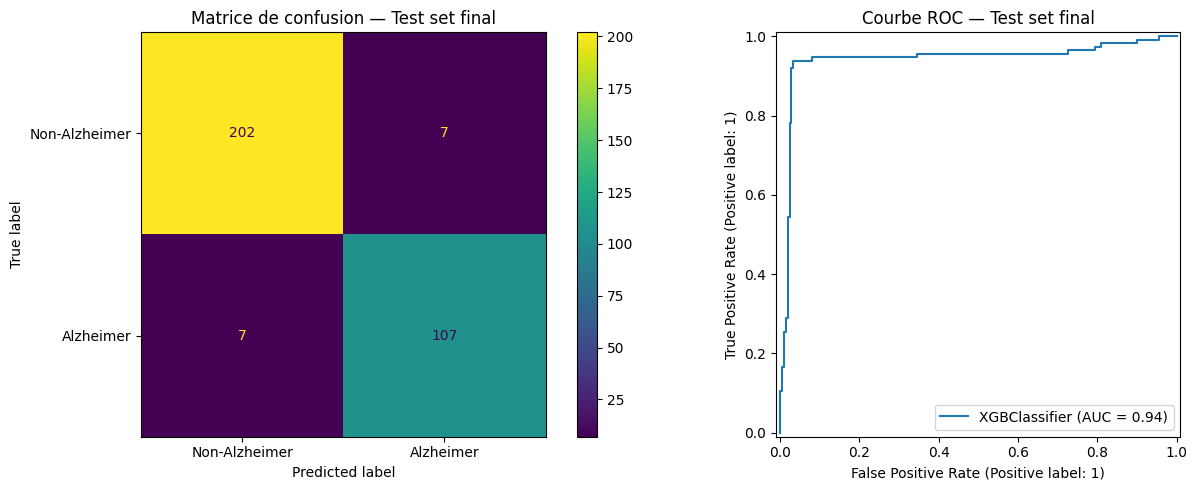

In [3]:
# Matrice de confusion + Courbe ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    xgb_model, X_test, y_test,
    display_labels=['Non-Alzheimer', 'Alzheimer'],
    ax=axes[0]
)
axes[0].set_title('Matrice de confusion — Test set final')

RocCurveDisplay.from_estimator(
    xgb_model, X_test, y_test, ax=axes[1]
)
axes[1].set_title('Courbe ROC — Test set final')

plt.tight_layout()
plt.savefig('../reports/final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Analyse des biais par genre
print('=== PERFORMANCE PAR GENRE ===')
from sklearn.metrics import recall_score, f1_score

for genre, label in [(0, 'Femme'), (1, 'Homme')]:
    mask = X_test['Gender'] == genre
    if mask.sum() > 0:
        r = recall_score(y_test[mask], y_pred[mask])
        f = f1_score(y_test[mask], y_pred[mask])
        print(f'{label} ({mask.sum()} patients) — Recall: {r:.3f} | F1: {f:.3f}')

# Analyse par tranche d'âge
print('\n=== PERFORMANCE PAR TRANCHE D\'ÂGE ===')
ages = pd.cut(X_test['Age'], bins=3, labels=['60-70', '70-80', '80-90'])
for tranche in ['60-70', '70-80', '80-90']:
    mask = ages == tranche
    if mask.sum() > 10:
        r = recall_score(y_test[mask], y_pred[mask])
        print(f'Âge {tranche} ({mask.sum()} patients) — Recall: {r:.3f}')

=== PERFORMANCE PAR GENRE ===
Femme (160 patients) — Recall: 0.934 | F1: 0.942
Homme (163 patients) — Recall: 0.943 | F1: 0.935

=== PERFORMANCE PAR TRANCHE D'ÂGE ===
Âge 60-70 (117 patients) — Recall: 0.897
Âge 70-80 (95 patients) — Recall: 0.933
Âge 80-90 (111 patients) — Recall: 0.978


In [5]:
# Analyse des biais par ethnicité
print('=== PERFORMANCE PAR ETHNICITÉ ===')

ethnicity_map = {
    0: 'Caucasien',
    1: 'Afro-Américain', 
    2: 'Asiatique',
    3: 'Autre'
}

for code, label in ethnicity_map.items():
    mask = X_test['Ethnicity'] == code
    if mask.sum() > 10:
        r = recall_score(y_test[mask], y_pred[mask])
        f = f1_score(y_test[mask], y_pred[mask])
        n = mask.sum()
        print(f'{label} ({n} patients) — Recall: {r:.3f} | F1: {f:.3f}')

=== PERFORMANCE PAR ETHNICITÉ ===
Caucasien (201 patients) — Recall: 0.947 | F1: 0.959
Afro-Américain (63 patients) — Recall: 0.944 | F1: 0.872
Asiatique (37 patients) — Recall: 0.857 | F1: 0.889
Autre (22 patients) — Recall: 1.000 | F1: 1.000
